# 1 - Vectors
Today we follow *Sam's Teach Yourself R in 24 Hours*:
- Hour 3: Single-mode data structures
- Hour 6: Common utility functions
- Hour 13: Graphics: high-level graphic functions

## Single-mode data structures

Basic data types:
- numeric
- logical (constants): `TRUE` or `T`, `FALSE` or `F`, and `NA` (missing value)
- character strings
- factor: (later)

In [ ]:
# character
"hello"

[1] "hello"

In [ ]:
# Numeric:
1+1*5*sqrt(7)

[1] 14.22876

In [ ]:
# Logical values can be combined via & (and) and | (or)
TRUE & FALSE
x <- 5
(x < 10) & (x > 3)

[1] FALSE

[1] TRUE

Missing value `NA` is contagious:

In [ ]:
NA + 1

In [ ]:
# Check mode (data type) of an object:
mode(7 * 5 + sqrt(2))
mode(x < 5)
mode(1 + NA)
mode("hello")

[1] "numeric"

[1] "logical"

[1] "numeric"

[1] "character"

## Vector
Use combine function `c()` on basic, single-mode data to get a vector.

In [ ]:
vec_1 <- c(1, 2, 3, 4, 5, 6, 7)
vec_2 <- c("Hello", "There")
mode(vec_1)
mode(vec_2)

[1] "numeric"

[1] "character"

In [ ]:
# c() coerces different modes into a single mode:
vec_3 <- c(1, TRUE, 2, FALSE, NA)
# c() works as flattened (not nested) concatenation on vectors:
c(vec_2,vec_3)

[1] "Hello" "There" "1"     "1"     "2"     "0"     NA

Use `:` to create increasing or decreasing sequence; use `seq` for finer-grained control.

In [ ]:
# Other ways to get vectors
5:1
1:5
2*(1:5)
seq(2,10,by = 2)
# Equally spaced between endpoints


[1] 5 4 3 2 1

[1] 1 2 3 4 5

[1]  2  4  6  8 10

[1]  2  4  6  8 10

## Aside: Getting help
To learn about a function, use
- `help(your_function)` or its alias `?your_function`
- Google, LLMs, www.rdocumentation.org/ (third-party).

In [ ]:
?seq

Use `rep` to repeat values:

In [ ]:
rep(1:3, 5)
rep("Hello", 3)

[1] 1 2 3 1 2 3 1 2 3 1 2 3 1 2 3

[1] "Hello" "Hello" "Hello"

## Vector: arithmetic & recycling

Two vectors add componentwise, with the shorter vector's entries "recycled" to match the length of the longer vector before adding. Similar for other operations.

In [ ]:
c(10,20,30,40,50) + c(2, 3)

Warning message in c(10, 20, 30, 40, 50) + c(2, 3):
“longer object length is not a multiple of shorter object length”


[1] 12 23 32 43 52

In [ ]:
# Multiplying and adding by scalars is consistent with recycling behavior:
2*c(50,60,70,80,90) + 1

[1] 101 121 141 161 181

## Vector: named vectors
Vector entries can be labelled with names.

You can create named vector directly.


In [ ]:
gender_freq <- c(Female = 10, Male = 5, NB = 3)
gender_freq

Female   Male     NB 
    10      5      3

Or add names to existing vector:

In [ ]:
gender_freq <- c(10, 5, 3)
names(gender_freq) <- c("Female", "Male", "NB")
gender_freq

Female   Male     NB 
    10      5      3

## Vector: subsetting aka subscripting
Subsetting behaves differently with different set of indices:

**Positive indices:** `vector[indices]` returns subvector keeping entries at those indices, written in the order of the indices.

**Negative indices:** `vector[indices]` returns subvector omitting those indices.

**Logical indices:** `vector[indices]` returns subvector keeping entries indexed by `TRUE`.


**Separately:** `my_vector[[index]]` and `my_vector[[index]]` (for named vector) returns the entry itself.

In [ ]:
# Results in error:
gender_freq[1,3]
gender_freq["Male", "Female"]

ERROR: Error in gender_freq[1, 3]: incorrect number of dimensions


In [ ]:
# Correct:
gender_freq[c(1,2)]
gender_freq[c("Female", "Male")]
gender_freq[-3]
gender_freq[c(T,T,F)]

Female   Male 
    10      5

Female   Male 
    10      5

Female   Male 
    10      5

Female   Male 
    10      5

In [ ]:
# Return all gender values with number > 4
# First get logical vayues of the indicies
gender_freq > 4
# Second use the logic vector for subsetting
gender_freq[gender_freq > 4]

In [ ]:
x <- c(1, 7, 2, 4, 6, 9, 2, 2)
# Reverse a vector:
x[8:1]
x[length(x):1]
rev(x)
# Want 2 2 9 6 4 2 7 1

[1] 2 2 9 6 4 2 7 1

[1] 2 2 9 6 4 2 7 1

[1] 2 2 9 6 4 2 7 1

In [ ]:
# Logical statements allow us to filter for desired entries:
x[x>6]
x[x>2 & x<5]

[1] 7 9

[1] 4

## Vector: numeric summary

**Statistical summary functions:**
- `mean`, `median`, standard deviation `sd`, variance `var`, `min`, `max`,  `sum`, vector `length`, `fivenum` gives the five-number summary (min, Q1, Q2, Q3, max).
- `range` of vector returns `c(min_value, max_value)` of that vector.

In [ ]:
range(c(1,6,9,3))
mean(c(1,1,2,2,3,3,NA))
# NA is contagious so it should be removed before calculating
mean(c(1,1,2,2,3,3,NA), na.rm = T)

[1] 1 9

[1] NA

[1] 2

## Basic graphs

`hist` — Histogram

`boxplot` — Boxplot

`qqnorm` — Normal quantile-quantile plot (normal Q-Q-plot) comparing quantiles of your dataset to the quantiles of the normal distribution.

`plot` — Plot points; has option to connect the dots to get line graph.

**Example.** A sample of high school boys and girls own certain number of shoes, shown below. Describe the two distributions (center, spread, shape, outlier).

In [ ]:
boy <- c(4, 5, 5, 5, 6, 7, 7, 7, 8, 10, 10, 10, 10, 11, 12, 14, 22, 35, 38)
girl <- c(13, 13, 13, 15, 20, 22, 23, 23, 24, 26, 26, 30, 31, 34, 38, 49, 50, 50, 51, 57)
fivenum(boy) # Min, Q1, Q2, Q3, Max
fivenum(girl)

[1]  4.0  6.5 10.0 11.5 38.0

[1] 13.0 21.0 26.0 43.5 57.0

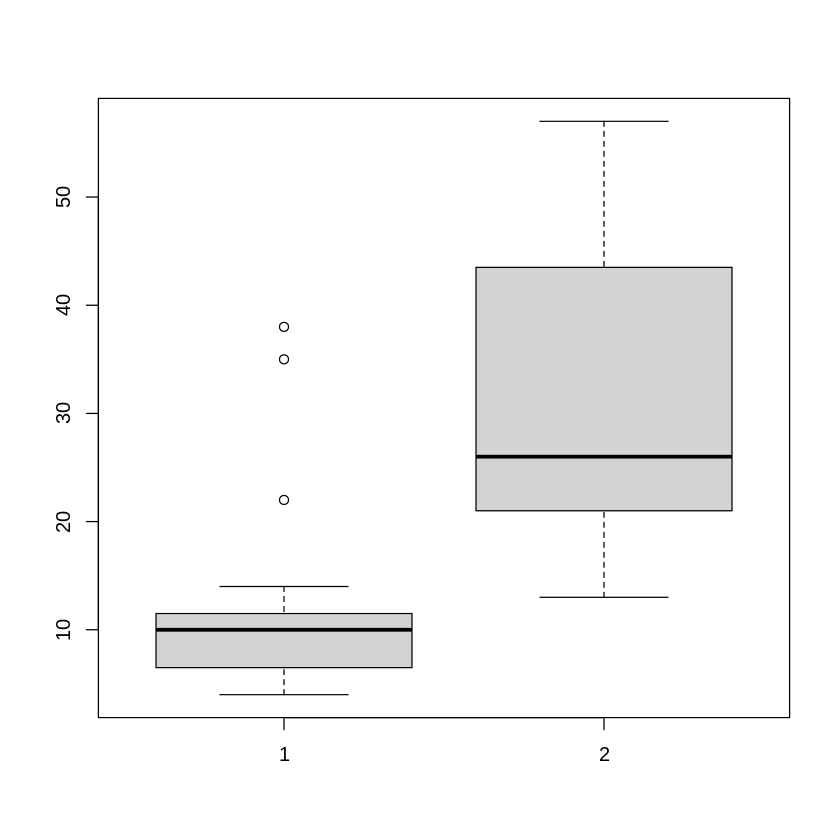

In [ ]:
boxplot(boy, girl)

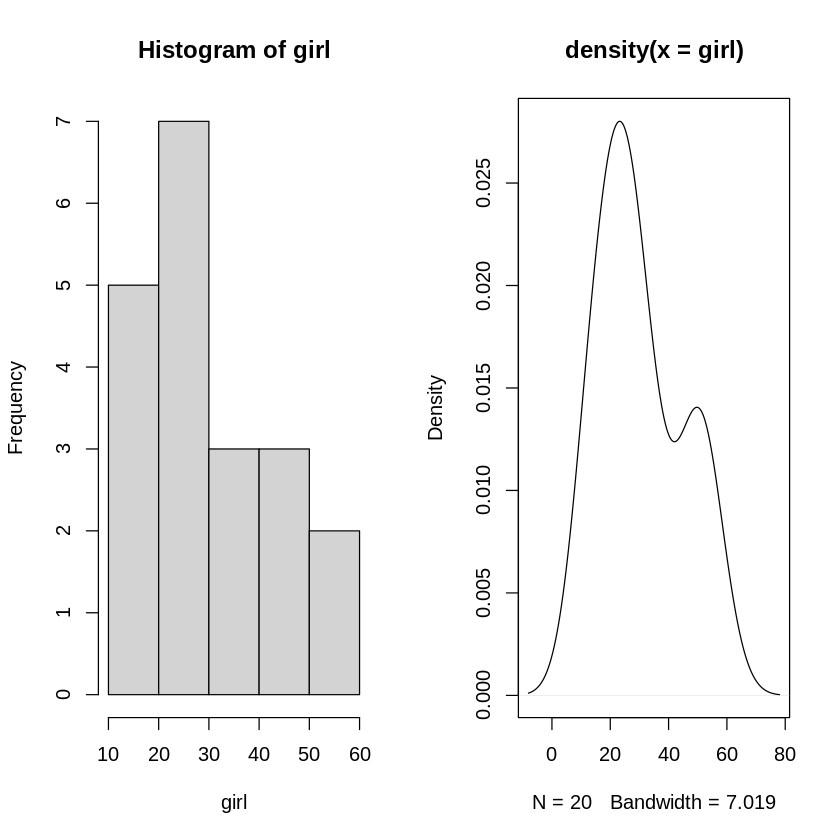

In [ ]:
par(mfrow = c(1, 2)) # plotting window as 1x2 grid
hist(girl)

plot(density(girl)) # kernel density estimate
par(mfrow = c(1, 1)) # reset plotting window back to 1x1 grid

## Common statistical distributions

The command format for using a statistical distribution is "letter" + "distribution name":
- Letter:
  - `d` for probability density function
  - `p` for cumulative distribution function
  - `q` for quantile function
  - `r` for random sampling
- Distribution:
  - `norm` normal
  - `poisson` poisson
  - `binom` binomial
  - `exp` exponential
  - `unif` uniform
  - `weibull` weibull
  - `beta` beta
  - `gamma` gamma
  - `f` f
  - `chisq` chi-squared

**Example.** The distribution of 20-29year-old male heights roughly follow a normal distribution with a mean of 70 inches and a standard deviation of 3 inches.

In [ ]:
# Estimate the 25th percentile of the data.


In [ ]:
# Estimate what percent of this population is between 67 inches and 74 inches in height.


In [ ]:
# Create a histogram of 100 values sampled from such a normal distribution.


# Activities: submit on Canvas at end of class
Work in groups. Today we will analyze various datasets of Billboard Weekly No. 1 songs:

## Activity A

**Dataset A.** Duration in seconds of songs that are Billboard No. 1 for 10+ weeks:

```
241, 232, 173, 157, 163, 227, 281, 167, 235, 289, 201, 240, 252, 236, 271, 177, 243, 253, 234, 244, 230, 265, 218, 250, 267, 235, 196, 199, 217, 248, 270, 260, 226, 186, 224, 164, 217, 173, 255, 235, 215, 230, 227, 208, 289, 227, 263, 224, 209
```

Questions:
1. How many songs are in the above dataset?
2. Convert the dataset from seconds into minutes.
3. Draw a boxplot and a histogram for the above dataset.
4. Determine the normal distribution that best fits the histogram of the above dataset. (Also explain what "best fits" means here.)

In [ ]:
Billboard <- c(241, 232, 173, 157, 163, 227, 281, 167, 235, 289, 201, 240, 252, 236, 271, 177, 243, 253, 234, 244, 230, 265, 218, 250, 267, 235, 196, 199, 217, 248, 270, 260, 226, 186, 224, 164, 217, 173, 255, 235, 215, 230, 227, 208, 289, 227, 263, 224, 209)

[1] 49

[1] 4 4 3 3 3 4 5 3 4 5 3 4 4 4 5 3 4 4 4 4 4 4 4 4 4 4 3 3 4 4 4 4 4 3 4 3 4 3
[39] 4 4 4 4 4 3 5 4 4 4 3

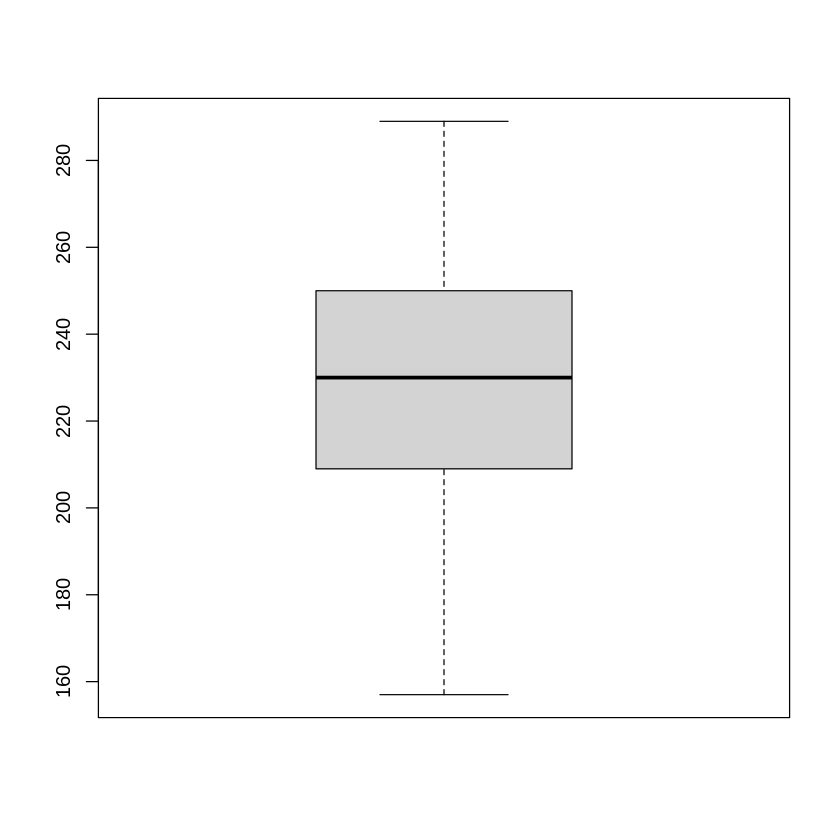

[1] 227.4082

[1] 33.6241

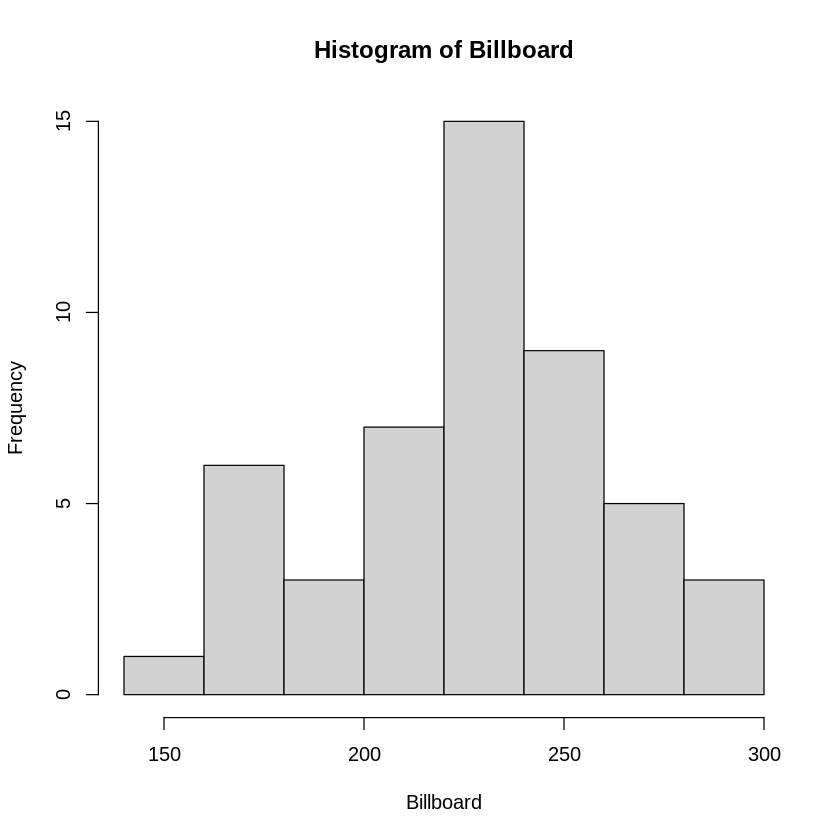

In [ ]:
# Your answers to Activity A here:
length(Billboard) # 49
round(Billboard/60)
boxplot(Billboard); hist(Billboard)
mean(Billboard); sd(Billboard)
# The normal distribution that best fits the histogram would have a mean of 227 and a sd of 33

## Activity B

Song titles of Billboard No. 1 songs (1991):
```
"Justify My Love", "Love Will Never Do (Without You)", "The First Time", "Gonna Make You Sweat (Everybody Dance Now)", "All the Man That I Need", "Someday", "One More Try", "Coming Out of the Dark", "I've Been Thinking About You", "You're in Love", "Baby Baby", "Joyride", "I Like the Way (The Kissing Game)", "I Don't Wanna Cry", "More Than Words", "Rush Rush", "Unbelievable", "(Everything I Do) I Do It for You", "The Promise of a New Day", "I Adore Mi Amor", "Good Vibrations", "Emotions", "Romantic", "Cream", "When a Man Loves a Woman", "Set Adrift on Memory Bliss", "Black or White"
```

Durations (seconds) of Billboard No. 1 songs (1991):
```
300, 350, 257, 243, 251, 245, 209, 270, 229, 253, 234, 264, 298, 289, 334, 292, 210, 394, 272, 290, 269, 249, 247, 253, 232, 250, 255
```

Song titles of Billboard No. 1 songs (2021):
```
"All I Want for Christmas Is You", "Mood", "Drivers License", "What's Next", "Up", "Peaches", "Montero (Call Me by Your Name)", "Leave the Door Open", "Rapstar", "Save Your Tears", "Good 4 U", "Butter", "Permission to Dance", "Stay", "Way 2 Sexy", "My Universe", "Industry Baby", "Easy on Me", "All Too Well (Taylor's Version)"
```

Durations (seconds) of Billboard No. 1 songs (2021):
```
241, 140, 242, 178, 156, 198, 192, 242, 165, 213, 178, 164, 187, 141, 258, 228, 212, 224, 613
```

Questions:
1. Identify outliers in song durations in the 1991 and the 2021 datasets. Explain if the outlier(s) in the 1991 dataset is more unusual or if the outlier(s) in the 2021 dataset is more unusual using some notion of spread, like interquartile range or standard deviation.
2. Standardize the 2021 song duration data vector so that its mean is zero and its standard deviation is 1. Do the same for the 2021 dataset.
3. Compare the distributions of length of song titles in 1991 versus the the distributions of length of song titles in 2021. (I.e.: compare their centers, spreads, shapes like skewness, outliers.)
4. Subset the vector of song names in the 2021 datasets so that only song names with more than 10 characters are returned.

In [ ]:
# Your answers to Activity B here:
